<a href="https://colab.research.google.com/github/NaimidE/Biodiversity_insects/blob/POR24/biodiversityPOR24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Screening: SysCom India- Participatory On Farm Reseach (POR) BIODIVERSITY Dataset

---

# Data


* Type
* Distribution

Import packages : pandas, numpy, seaborn & matplotlib

In [ ]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn as sns


## Reading and making available the dataset


In [ ]:
from google.colab import files
uplouded  = files.upload()

Saving POR24_beneficial.csv to POR24_beneficial.csv


In [ ]:
df = pd.read_csv('POR24_beneficial.csv')
df[:3]
len(df)

420

# Setting, Analysis, distribution
transforming variables to numeric, dtype: int64

In [ ]:
# Get the column names starting from the 10th column
cols_to_convert = df.columns[9:]

# Convert the selected columns to numeric, coercing errors
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')
print(df[cols_to_convert].dtypes)

Spider_Lower                  int64
Syrphid_adult_Lower           int64
Syrphid_juvenile_Lower        int64
Syrphid_Eggs_Lower            int64
Ladybug_adult_Lower           int64
ladybug_juvenile_Lower        int64
Ladybug_Eggs_Lower            int64
Lacewing_adult_Lower          int64
Lacewing_juvenile_Lower       int64
Lacewing_Eggs_Lower           int64
Spider_Middle                 int64
Syrphid_adult_Middle          int64
Syrphid_juvenile_Middle       int64
Syrphid_Eggs_Middle           int64
Ladybug_adult_Middle          int64
Ladybug_juvenile_Middle       int64
Ladybug_Eggs_Middle           int64
Lacewing_adult_Middle         int64
Lacewing_juvenile_Middle      int64
Lacewing_Eggs_Middle          int64
Spider_Upper                  int64
Syrphid_adult_Upper           int64
Syrphid_juvenile_Upper        int64
Syrphid_eggs_Upper            int64
Ladybug_adult_Upper           int64
Ladybug_juvenile_Upper        int64
Ladybug_Eggs_Upper          float64
Lacewing_adult_Upper        

In [ ]:
# Eliminate spaces in the name of the colums

df.columns = df.columns.str.replace(' ', '')
df.columns

Index(['Year', 'Survey_No', 'Date', 'Month', 'Village', 'Farmer_name', 'Pair',
       'Treatment', 'Pl1nt.No.', 'Spider_Lower', 'Syrphid_adult_Lower',
       'Syrphid_juvenile_Lower', 'Syrphid_Eggs_Lower', 'Ladybug_adult_Lower',
       'ladybug_juvenile_Lower', 'Ladybug_Eggs_Lower', 'Lacewing_adult_Lower',
       'Lacewing_juvenile_Lower', 'Lacewing_Eggs_Lower', 'Spider_Middle',
       'Syrphid_adult_Middle', 'Syrphid_juvenile_Middle',
       'Syrphid_Eggs_Middle', 'Ladybug_adult_Middle',
       'Ladybug_juvenile_Middle', 'Ladybug_Eggs_Middle',
       'Lacewing_adult_Middle', 'Lacewing_juvenile_Middle',
       'Lacewing_Eggs_Middle', 'Spider_Upper', 'Syrphid_adult_Upper',
       'Syrphid_juvenile_Upper', 'Syrphid_eggs_Upper', 'Ladybug_adult_Upper',
       'Ladybug_juvenile_Upper', 'Ladybug_Eggs_Upper', 'Lacewing_adult_Upper',
       'Lacewing_juvenile_Upper', 'Lacewing_Eggs_Upper', 'SoilMoiture',
       'Ladybug', 'Spider', 'Lacewing', 'Syrphid', 'ladybug_adult',
       'ladybug_juveni

In [ ]:

# Get the column names starting from the 10th column
cols_to_convert = df.columns[9:]

# Convert the selected columns to numeric, coercing errors
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# Fill NaN values with 0 and convert to int64
df[cols_to_convert] = df[cols_to_convert].fillna(0).astype('int64')

df[cols_to_convert].dtypes


,0
Spider_Lower,int64
Syrphid_adult_Lower,int64
Syrphid_juvenile_Lower,int64
Syrphid_Eggs_Lower,int64
Ladybug_adult_Lower,int64
ladybug_juvenile_Lower,int64
Ladybug_Eggs_Lower,int64
Lacewing_adult_Lower,int64
Lacewing_juvenile_Lower,int64
Lacewing_Eggs_Lower,int64


In [ ]:
# columns categories of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 53 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      420 non-null    int64 
 1   Survey_No                 420 non-null    object
 2   Date                      420 non-null    object
 3   Month                     420 non-null    object
 4   Village                   420 non-null    object
 5   Farmer_name               420 non-null    object
 6   Pair                      420 non-null    int64 
 7   Treatment                 420 non-null    object
 8   Pl1nt.No.                 420 non-null    int64 
 9   Spider_Lower              420 non-null    int64 
 10  Syrphid_adult_Lower       420 non-null    int64 
 11  Syrphid_juvenile_Lower    420 non-null    int64 
 12  Syrphid_Eggs_Lower        420 non-null    int64 
 13  Ladybug_adult_Lower       420 non-null    int64 
 14  ladybug_juvenile_Lower    

In [ ]:
# column month

df['Month'].unique()

array(['June', 'July', 'Aug-01', 'Aug-02', 'Sep-01', 'Sep-02', 'October'],
      dtype=object)

In [ ]:
df['Month'] = df['Month'].replace({'Aug-01': 'Early August', 'Aug-02': 'Late August', 'Sep-01': 'Early September', 'Sep-02': 'Late September'})
df['Month'].unique()

array(['June', 'July', 'Early August', 'Late August', 'Early September',
       'Late September', 'October'], dtype=object)

new columns to be analized: Ladybug, Spider, Lacewing and Syrphid

# Analysis Beneficial Insects

## Distribution graph for Ladybug	Spider	Lacewing and Syrphid vs month


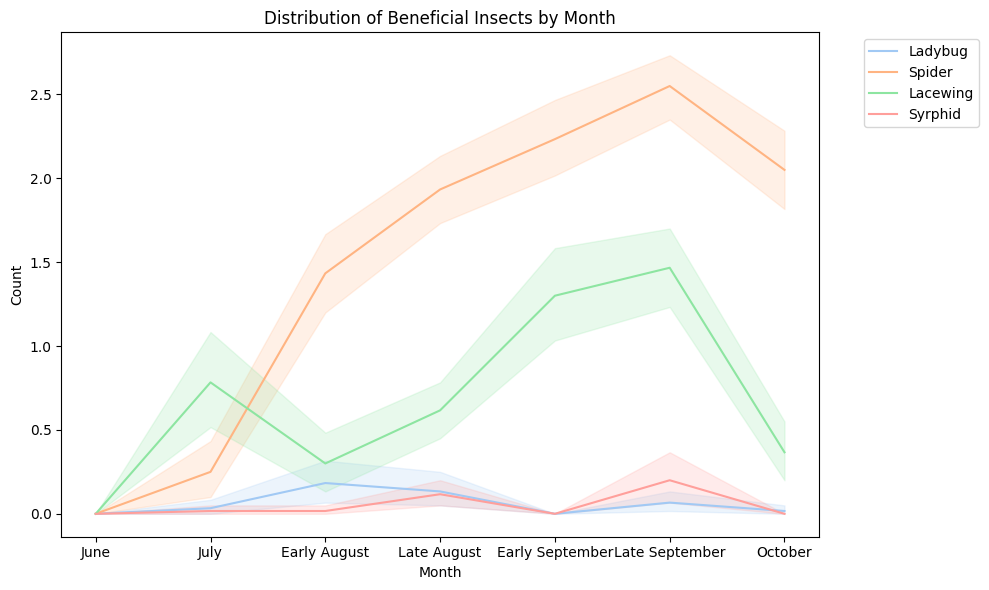

In [ ]:
# Prepare data for plotting
df_plot = df.melt(id_vars=['Month'], value_vars=['Ladybug', 'Spider', 'Lacewing', 'Syrphid'],
                  var_name='Beneficial Insect', value_name='Count')

# Order months
month_order = ['June', 'July', 'Early August', 'Late August', 'Early September',
       'Late September', 'October']
df_plot['Month'] = pd.Categorical(df_plot['Month'], categories=month_order, ordered=True)

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='Month', y='Count', hue='Beneficial Insect', palette='pastel')

# Add labels and title
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Distribution of Beneficial Insects by Month')

# Place legend outside the plot to the upper right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

# Distribution graphs for the Ladybug	Spider	Lacewing and Syrphid vs month by treatment: ORG vs BT.


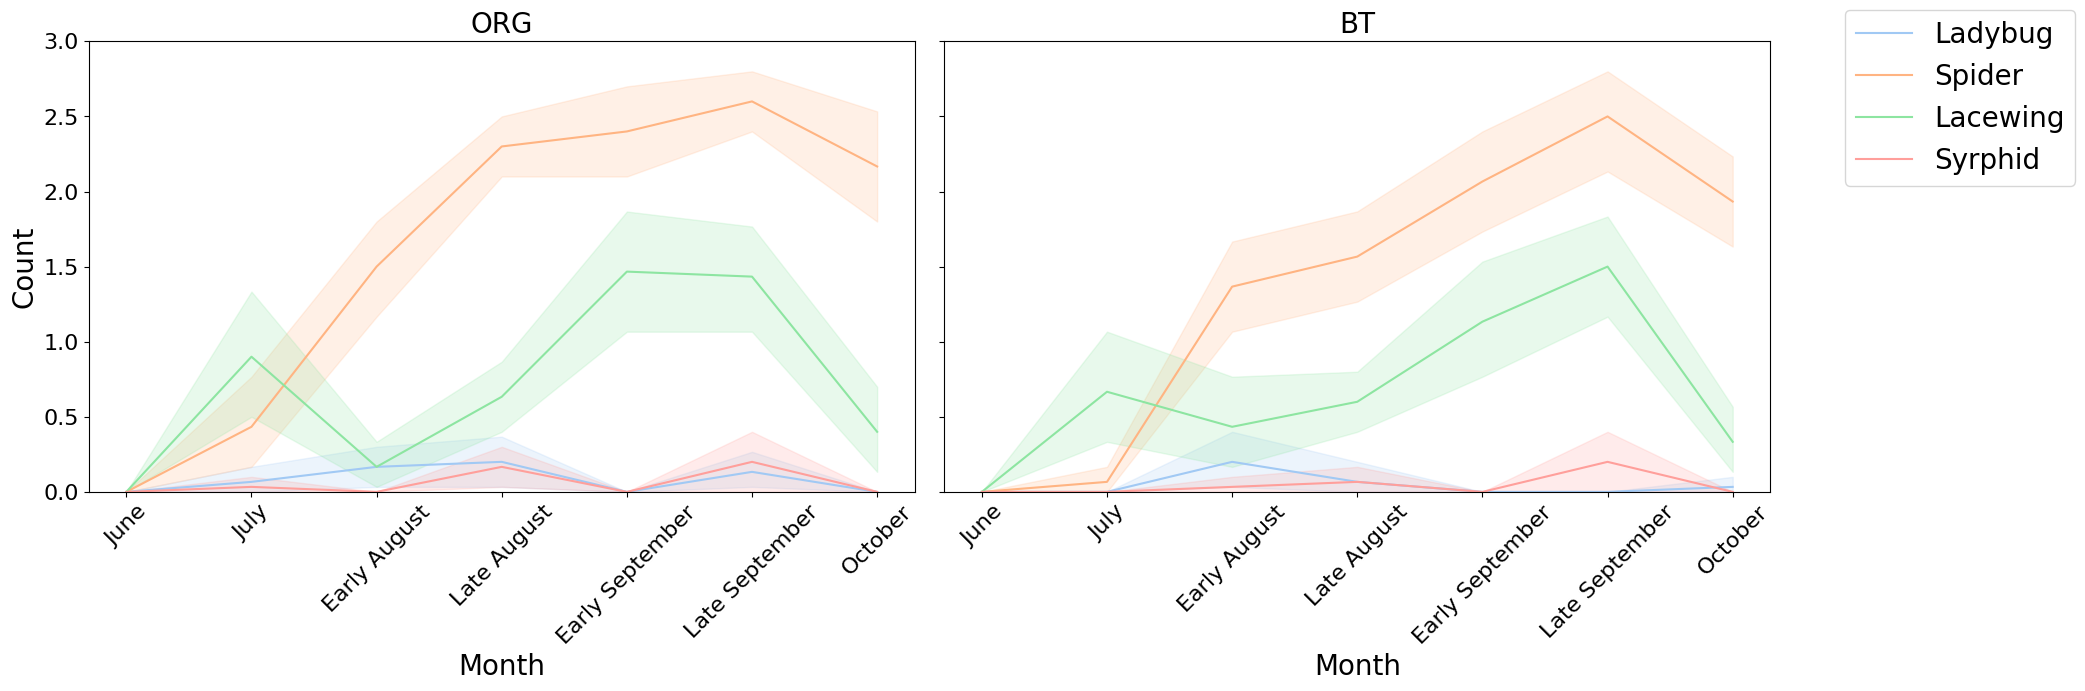

In [ ]:
# Filter data by treatment
df_org = df[df['Treatment'] == 'ORG'].melt(id_vars=['Month'], value_vars=['Ladybug', 'Spider', 'Lacewing', 'Syrphid'],
                                            var_name='Beneficial Insect', value_name='Count')
df_bt = df[df['Treatment'] == 'BT'].melt(id_vars=['Month'], value_vars=['Ladybug', 'Spider', 'Lacewing', 'Syrphid'],
                                          var_name='Beneficial Insect', value_name='Count')

# Order months
month_order = ['June', 'July', 'Early August', 'Late August', 'Early September',
       'Late September', 'October']
df_org['Month'] = pd.Categorical(df_org['Month'], categories=month_order, ordered=True)
df_bt['Month'] = pd.Categorical(df_bt['Month'], categories=month_order, ordered=True)

# Determine the maximum count across both treatments for consistent y-axis limits
max_count = max(df_org['Count'].max(), df_bt['Count'].max())

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot for ORG treatment
sns.lineplot(ax=axes[0], data=df_org, x='Month', y='Count', hue='Beneficial Insect', palette='pastel')
axes[0].set_title('ORG', fontsize=20)
axes[0].set_xlabel('Month', fontsize=20)
axes[0].set_ylabel('Count', fontsize=20)
axes[0].set_ylim(0, max_count * 1.1) # Set y-axis limit slightly above max count
axes[0].get_legend().remove() # Remove individual subplot legend
axes[0].tick_params(axis='x', labelsize=16,  rotation=45) # Set x-axis tick label size
axes[0].tick_params(axis='y', labelsize=16) # Set y-axis tick label size

# Plot for BT treatment
sns.lineplot(ax=axes[1], data=df_bt, x='Month', y='Count', hue='Beneficial Insect', palette='pastel')
axes[1].set_title('BT', fontsize=20)
axes[1].set_xlabel('Month', fontsize=20)
axes[1].set_ylabel('') # No y-label on the second plot as they are shared
axes[1].set_ylim(0, 3) # Set same y-axis limit
axes[1].get_legend().remove() # Remove individual subplot legend
axes[1].tick_params(axis='x', labelsize=16,  rotation=45) # Set x-axis tick label size

# Create a common legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=20)


# Improve layout
plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to make space for the legend

# Show the plot
plt.show()

Exploration with Seaborn:
Distribution plots `displot`(histograma de frecuencias)
https://seaborn.pydata.org/tutorial/distributions.html



## Stacked barplot graph for Ladybug	Spider	Lacewing and Syrphid vs month (order: June, July, August, September, October).


/tmp/ipython-input-1970937657.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot = df_plot.pivot_table(index='Month', columns='Beneficial Insect', values='Count', aggfunc='sum')


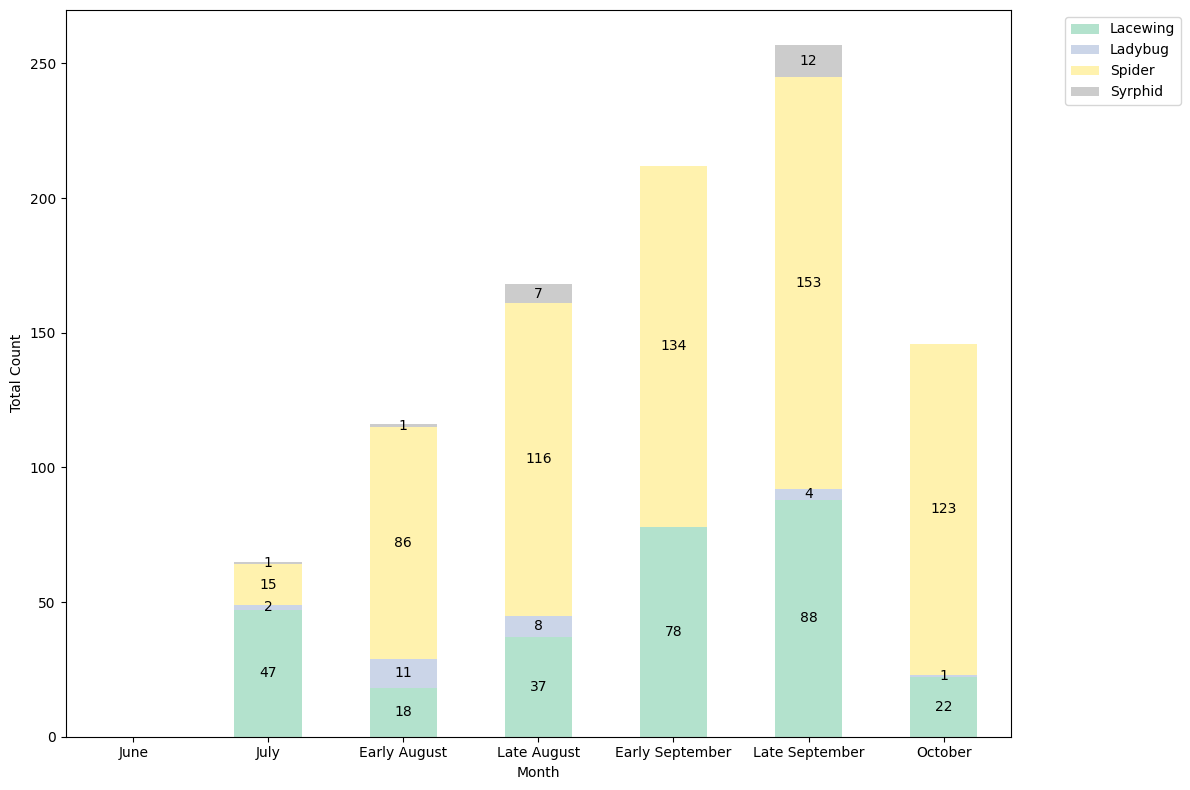

In [ ]:
# Pivot the dataframe to get months as index and beneficial insects as columns
df_pivot = df_plot.pivot_table(index='Month', columns='Beneficial Insect', values='Count', aggfunc='sum')

# Reindex to ensure month order
df_pivot = df_pivot.reindex(month_order)

# Create the stacked bar plot
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Pastel2')

# Add labels and title
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.title('')

# Place legend outside the plot to the upper right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add total values on top of each stack
for c in ax.containers:
    # Add the integer value of the bar
    labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

# Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

## Stacked barplot for the columns: Ladybug	Spider, Lacewing and Syrphid vs month (order: June, July, August, September, October) separated by Treatment.

/tmp/ipython-input-1207029600.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(ordered_insects))
/tmp/ipython-input-1207029600.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot_treatment = df_treatment.pivot_table(index='Month', columns='Beneficial Insect', values='Count', aggfunc='sum').reindex(month_order)
/tmp/ipython-input-1207029600.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot_treatment = df_treatment.pivot_table

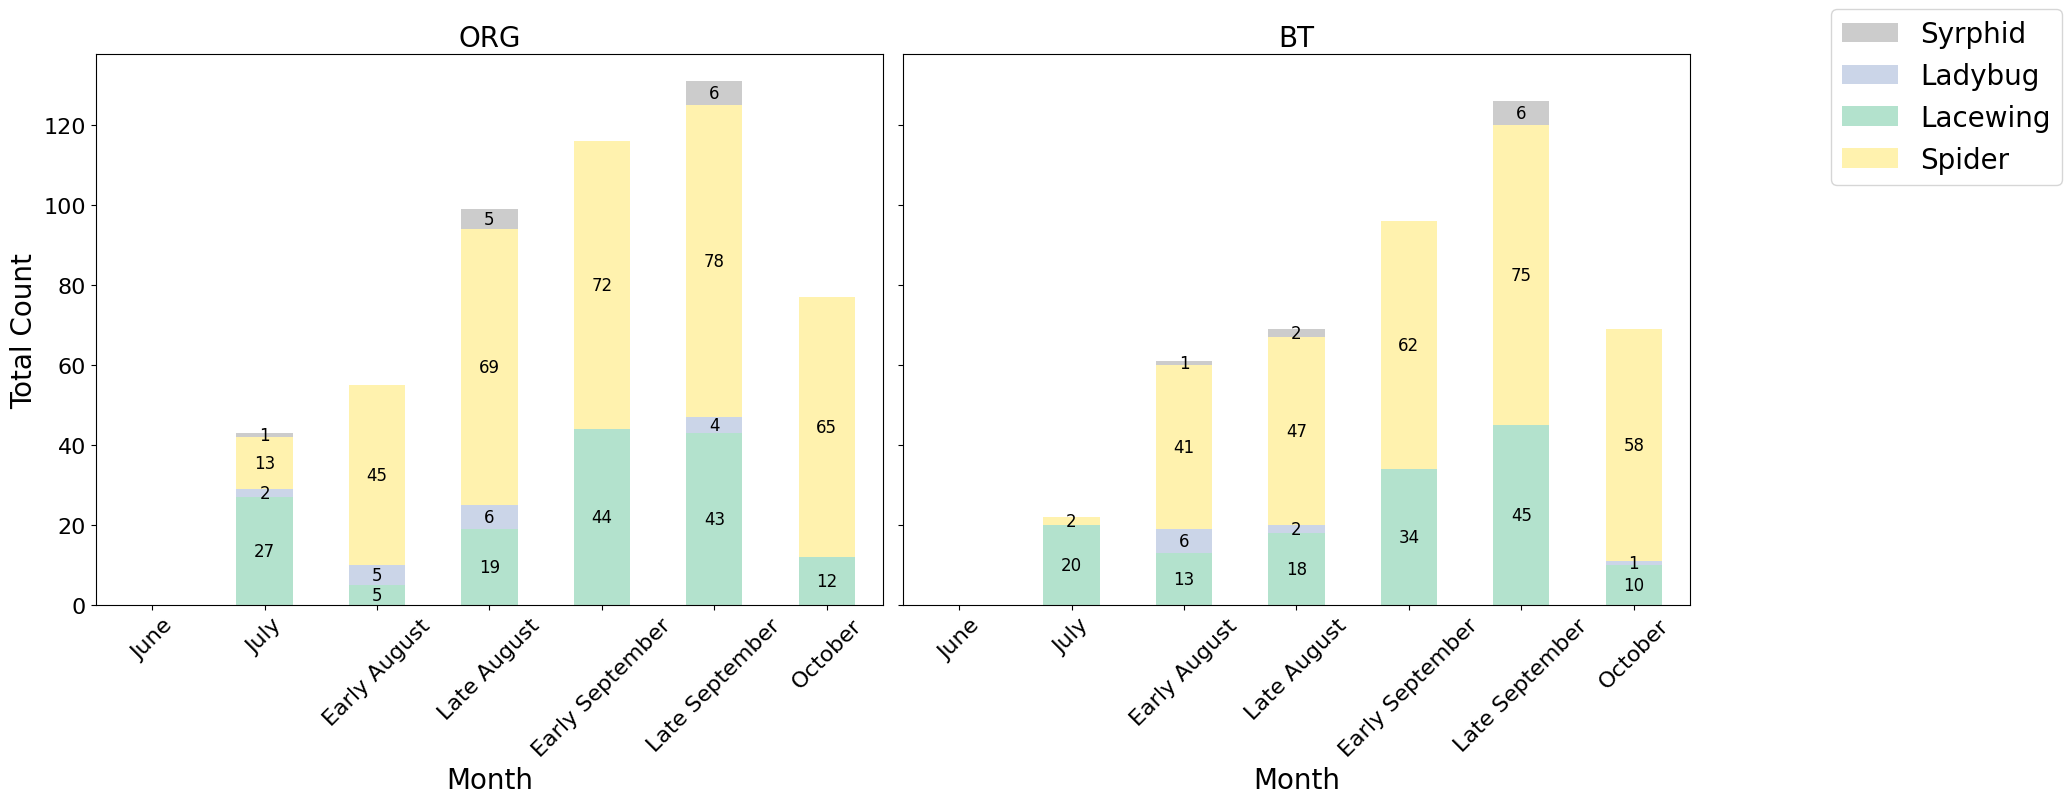

In [ ]:
# Filter the DataFrame to include only the relevant columns and order them by total value
df_filtered = df[['Treatment', 'Month', 'Ladybug', 'Spider', 'Lacewing', 'Syrphid']].copy()

# Calculate the total count for each beneficial insect across all months and treatments
totals = df_filtered[['Ladybug', 'Spider', 'Lacewing', 'Syrphid']].sum().sort_values(ascending=True)

# List of beneficial insects
ordered_insects = totals.index.tolist()

# Reorder the columns in the DataFrame based on the total counts
df_filtered = df_filtered[['Treatment', 'Month'] + ordered_insects]

# Melt the DataFrame for plotting
df_melted = df_filtered.melt(id_vars=['Treatment', 'Month'], value_vars=ordered_insects,
                            var_name='Beneficial Insect', value_name='Count')

# Order months
month_order = ['June', 'July', 'Early August', 'Late August', 'Early September',
       'Late September', 'October']
df_melted['Month'] = pd.Categorical(df_melted['Month'], categories=month_order, ordered=True)

# Get unique treatments
treatments = df_melted['Treatment'].unique()

# Create subplots for each treatment with shared y-axis
fig, axes = plt.subplots(1, len(treatments), figsize=(18, 8), sharey=True)

# Define a light color palette based on the number of insects
colors = plt.cm.get_cmap('Pastel2', len(ordered_insects))
color_palette = [colors(i) for i in range(len(ordered_insects))]

for i, treatment in enumerate(treatments):
    ax = axes[i]
    df_treatment = df_melted[df_melted['Treatment'] == treatment]

    # Pivot data for stacked bar plot
    df_pivot_treatment = df_treatment.pivot_table(index='Month', columns='Beneficial Insect', values='Count', aggfunc='sum').reindex(month_order)

    # Create stacked bar plot
    df_pivot_treatment.plot(kind='bar', stacked=True, ax=ax, color=color_palette, legend=False)

    # Add labels and title
    ax.set_xlabel('Month', fontsize=20)
    if i == 0: # Only add ylabel to the first subplot
        ax.set_ylabel('Total Count', fontsize=20)
    ax.set_title(treatment, fontsize=20)
    axes[0].tick_params(axis='x', labelsize=16)
    axes[1].tick_params(axis='x', labelsize=16)
    axes[0].tick_params(axis='y', labelsize=16)

    # Add integer values inside each bar segment
    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=12)

    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

# Create a single legend for both plots
handles, labels = axes[0].get_legend_handles_labels()
# Order legend based on total values (highest to smallest)
ordered_handles = [handles[labels.index(insect)] for insect in ordered_insects]
ordered_labels = ordered_insects

fig.legend(ordered_handles, ordered_labels, fontsize=20,
           bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Improve layout
plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to make space for the legend

# Show the plot
plt.show()


# Analysis Phytophagous Insects

In [ ]:
from google.colab import files
uplouded  = files.upload()

Saving POR24_phytophag.csv to POR24_phytophag.csv


In [ ]:
df2 = pd.read_csv('POR24_phytophag.csv')
df2[:3]
len(df2)

420

In [ ]:
# Get the column names starting from the 10th column
cols_to_convert = df2.columns[9:]

# Convert the selected columns to numeric, coercing errors
df2[cols_to_convert] = df2[cols_to_convert].apply(pd.to_numeric, errors='coerce')
print(df2[cols_to_convert].dtypes)

Jassid_Lower_leaf                int64
Jassid_Middle_leaf               int64
Jassid_Upper_leaf                int64
Whitefly_Lower_leaf              int64
Whitefly_Middle_leaf             int64
Whitefly_Upper_leaf              int64
Aphid_Lower_leaf                 int64
Aphid_Middle_leaf                int64
Aphid_Upper_leaf                 int64
Thrip_Lower_leaf                 int64
Thrip_Middle_leaf                int64
Thrip_Upper_leaf                 int64
Mealybugs_(0-4)_whole_plant      int64
Soil Moiture                   float64
dtype: object


In [ ]:
# Eliminate spaces in the name of the colums

df2.columns = df2.columns.str.replace(' ', '')
df2.columns

Index(['Year', 'Survey_No', 'Date', 'Month', 'Village', 'Farmer_name', 'Pair',
       'Treatment', 'Pl1nt.No.', 'Jassid_Lower_leaf', 'Jassid_Middle_leaf',
       'Jassid_Upper_leaf', 'Whitefly_Lower_leaf', 'Whitefly_Middle_leaf',
       'Whitefly_Upper_leaf', 'Aphid_Lower_leaf', 'Aphid_Middle_leaf',
       'Aphid_Upper_leaf', 'Thrip_Lower_leaf', 'Thrip_Middle_leaf',
       'Thrip_Upper_leaf', 'Mealybugs_(0-4)_whole_plant', 'SoilMoiture'],
      dtype='object')

In [ ]:
#
df2['Jassid'] = df2[['Jassid_Lower_leaf',	'Jassid_Middle_leaf',	'Jassid_Upper_leaf']].mean(axis=1)
df2['Whitefly'] = df2[['Whitefly_Lower_leaf',	'Whitefly_Middle_leaf',	'Whitefly_Upper_leaf']].mean(axis=1)
df2['Aphid'] = df2[['Aphid_Lower_leaf',	'Aphid_Middle_leaf', 'Aphid_Upper_leaf']].mean(axis=1)
df2['Thrip'] = df2[['Thrip_Lower_leaf',	'Thrip_Middle_leaf', 'Thrip_Upper_leaf']].mean(axis=1)

df2.to_csv('POR24phytop_mean.csv', index=False)
files.download('POR24phytop_mean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df2['Month'] = df2['Month'].replace({'Aug-01': 'August', 'Sep-01': 'September'})
df2['Month'].unique()

array(['June', 'July', 'August', 'Aug-02', 'September', 'Sep-02',
       'October'], dtype=object)

In [ ]:
print(df2.dtypes)

Year                             int64
Survey_No                       object
Date                            object
Month                           object
Village                         object
Farmer_name                     object
Pair                             int64
Treatment                       object
Pl1nt.No.                        int64
Jassid_Lower_leaf                int64
Jassid_Middle_leaf               int64
Jassid_Upper_leaf                int64
Whitefly_Lower_leaf              int64
Whitefly_Middle_leaf             int64
Whitefly_Upper_leaf              int64
Aphid_Lower_leaf                 int64
Aphid_Middle_leaf                int64
Aphid_Upper_leaf                 int64
Thrip_Lower_leaf                 int64
Thrip_Middle_leaf                int64
Thrip_Upper_leaf                 int64
Mealybugs_(0-4)_whole_plant      int64
SoilMoiture                    float64
Jassid                         float64
Whitefly                       float64
Aphid                    

In [ ]:
# column month: the month Aug-02 and Sep-02 were not considered

df2['Month'].unique()

array(['June', 'July', 'August', 'Aug-02', 'September', 'Sep-02',
       'October'], dtype=object)

## Graphs



### Phytophagous vs time


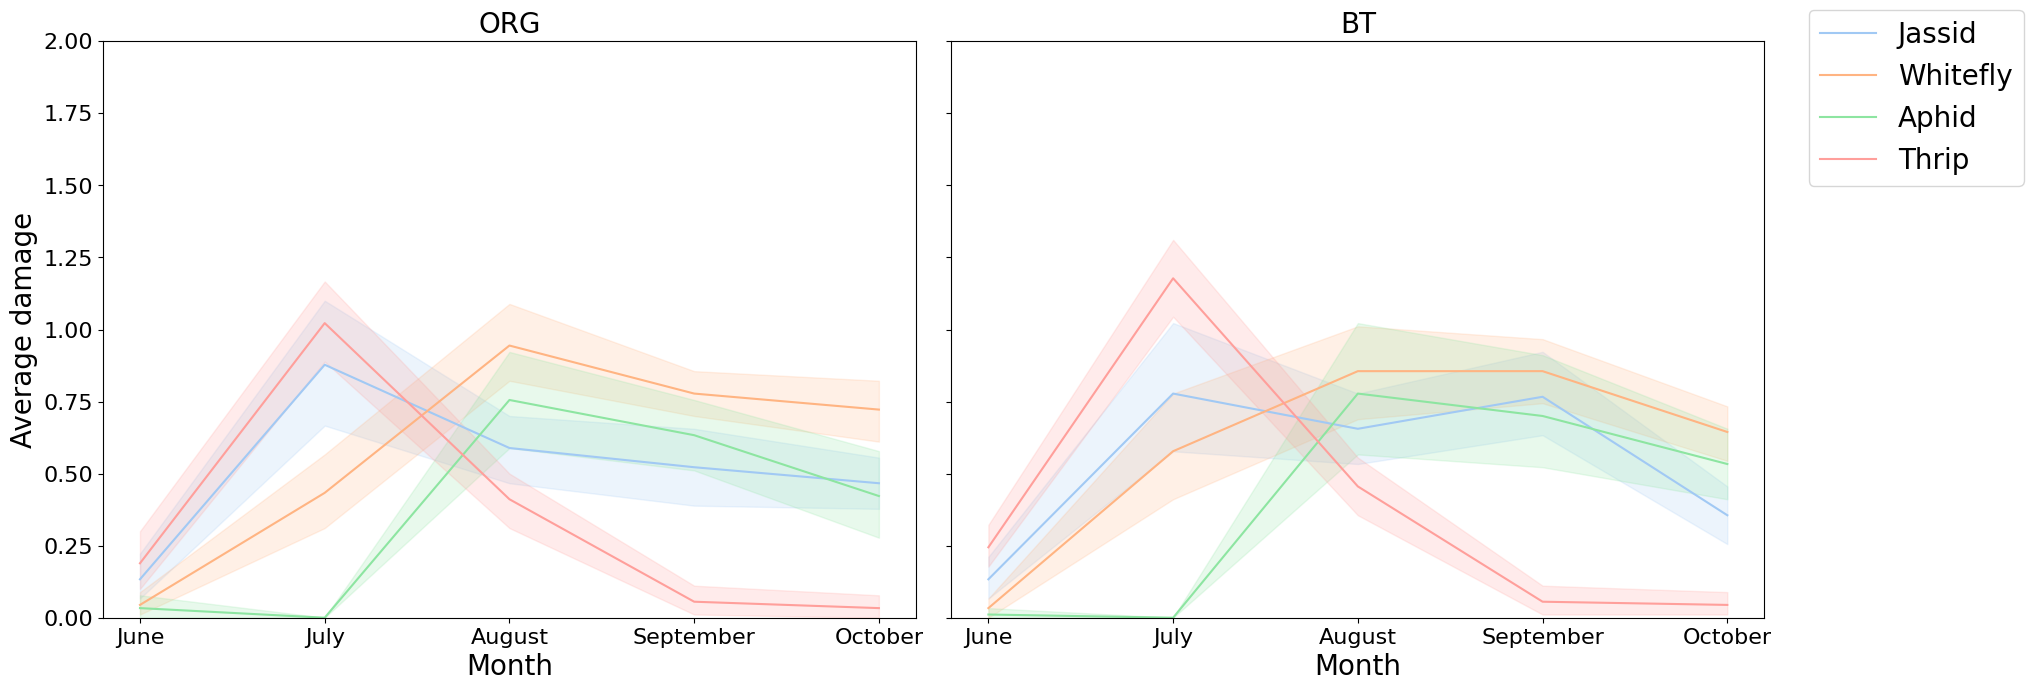

In [ ]:
# Filter data by treatment
df_org = df2[df2['Treatment'] == 'ORG'].melt(id_vars=['Month'], value_vars=['Jassid', 'Whitefly', 'Aphid', 'Thrip'],
                                            var_name='Phytophagous', value_name='Average damage')
df_bt = df2[df2['Treatment'] == 'BT'].melt(id_vars=['Month'], value_vars=['Jassid', 'Whitefly', 'Aphid', 'Thrip'],
                                          var_name='Phytophagous', value_name='Average damage')

# Order months
month_order = ['June', 'July', 'August', 'September', 'October']
df_org['Month'] = pd.Categorical(df_org['Month'], categories=month_order, ordered=True)
df_bt['Month'] = pd.Categorical(df_bt['Month'], categories=month_order, ordered=True)

# Determine the maximum count across both treatments for consistent y-axis limits
max_count = max(df_org['Average damage'].max(), df_bt['Average damage'].max())

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot for ORG treatment
sns.lineplot(ax=axes[0], data=df_org, x='Month', y='Average damage', hue='Phytophagous', palette='pastel')
axes[0].set_title('ORG', fontsize=20)
axes[0].set_xlabel('Month', fontsize=20)
axes[0].set_ylabel('Average damage', fontsize=20)
axes[0].set_ylim(0, max_count * 1.1) # Set y-axis limit slightly above max count
axes[0].get_legend().remove() # Remove individual subplot legend
axes[0].tick_params(axis='x', labelsize=16)
axes[1].tick_params(axis='x', labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)

# Plot for BT treatment
sns.lineplot(ax=axes[1], data=df_bt, x='Month', y='Average damage', hue='Phytophagous', palette='pastel')
axes[1].set_title('BT', fontsize=20)
axes[1].set_xlabel('Month', fontsize=20)
axes[1].set_ylabel('') # No y-label on the second plot as they are shared
axes[1].set_ylim(0,2) # Set same y-axis limit
axes[1].get_legend().remove() # Remove individual subplot legend


# Create a common legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=20, loc='upper left', bbox_to_anchor=(1.0, 1))


# Improve layout
plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to make space for the legend

# Show the plot
plt.show()

### Phytophagous vs humidity
```



## How is the distribution of the different families of insect per time and agrosystem?**

In [ ]:
from google.colab import files
uplouded  = files.upload()

Saving 25_02_21_POR24_Bio_GA_R.csv to 25_02_21_POR24_Bio_GA_R.csv


In [ ]:
df3 = pd.read_csv('25_02_21_POR24_Bio_GA_R.csv')
df3[:3]
len(df3)

240

## Histogram of columns: Aranea	Diptera	Dermaptera	Orthoptera	Coleoptera	Blattodae	Isopoda	Diplopoda	Hymenoptera : to be done

In [ ]:
# Melt the dataframe to long format
df_melted = df3.melt(
    id_vars=['Date', 'System'],
    value_vars=['Aranea', 'Diptera', 'Dermaptera', 'Orthoptera', 'Coleoptera', 'Blattodae', 'Isopoda', 'Diplopoda', 'Hymenoptera', 'Other'],
    var_name='Insect Family',
    value_name='Count'
)

# Convert 'Date' to datetime objects and extract just the date part
df_melted['Date'] = pd.to_datetime(df_melted['Date']).dt.date

# Sort by date
df_melted = df_melted.sort_values(by='Date')

# Get unique systems for subplots
systems = df_melted['System'].unique()

# Set up the plot with subplots for each system
fig, axes = plt.subplots(1, len(systems), figsize=(18, 7), sharey=True)

# Define a professional color palette
colors = plt.cm.get_cmap('viridis', len(df_melted['Insect Family'].unique()))
color_palette = [colors(i) for i in range(len(df_melted['Insect Family'].unique()))]

for i, system in enumerate(systems):
    ax = axes[i]
    df_system = df_melted[df_melted['System'] == system]

    # Pivot data for stacked bar plot per date
    df_pivot_system = df_system.pivot_table(index='Date', columns='Insect Family', values='Count', aggfunc='sum').fillna(0)

    # Create stacked bar plot
    df_pivot_system.plot(kind='bar', stacked=True, ax=ax, color=color_palette, legend=False)

    # Add labels and title
    ax.set_xlabel('Date')
    if i == 0:  # Add y-label only to the first subplot
        ax.set_ylabel('Total Count')
    ax.set_title(system)

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

# Create a single legend for both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Insect Family',
           bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Improve layout
plt.tight_layout(rect=[0, 0, 0.95, 1])  # Adjust layout to make space for the legend

# Set a main title for the entire figure
fig.suptitle('Distribution of Insect Families by Date and System', fontsize=16, y=1.02)

# Show the plot
plt.show()


<ipython-input-46-9b3775651306>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_melted['Date'] = pd.to_datetime(df_melted['Date']).dt.date


OutOfBoundsDatetime: Out of bounds nanosecond timestamp: June, at position 0

In [ ]:
sns.countplot(y='Aranea', x='Date', hue='System',data=df3)
plt.title('Does the farmer produce compost on their farm?')
plt.show()


TypeError: Cannot pass values for both `x` and `y`.